# Statistical Modeling of Earthquake Parameters
## Data Cleaning & Preparation

In [28]:
library(tidyverse)
library(lubridate)

df <- read_csv("turkiye_data.csv") 
library(dplyr)
library(stringr)

sites <- c("HATAY", "MUGLA", "IZMIR", "MALATYA", "MANISA", "ÇANAKKALE")

turkiye <- df %>%
  filter(Type == "MW", Magnitude >= 4, Depth <= 75) %>%
  mutate(
    Site = str_extract(Location, "(?<=\\().+?(?=\\))"),  
    Site = toupper(Site),                             
    SiteCat = case_when(
      Site %in% sites ~ Site,                    
      TRUE ~ "Other"                                        
    ),
    Year = year(dmy_hm(EventDate))
  )

turkiye %>% count(SiteCat)

Rows: 9975 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): EventDate, EpicenterAgency, Type, Location
dbl (5): EventID, EpicenterLon, EpicenterLat, Magnitude, Depth

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


SiteCat,n
<chr>,<int>
HATAY,46
IZMIR,103
MALATYA,159
MANISA,73
MUGLA,196
Other,1980
ÇANAKKALE,62


In [38]:
library(stringr)
pacific_nw = read.csv("pacific-nw-data.csv")
pacific_nw = pacific_nw %>% filter(magnitude >= 4 & depth <= 75)

# Assuming your dataframe is called df
pacific_nw <- pacific_nw %>%
  mutate(
    state = str_extract(place, ", ([A-Z]{2})$") %>%  # extract last two letters after comma
            str_remove_all(", ")                     # remove comma/space
  )

# Optional: check unique states
unique(pacific_nw$state)

pacific_nw <- pacific_nw %>%
  mutate(
    state = if_else(state %in% c("WA","OR","ID","BC","CA"), state, NA_character_),
    year = year(ymd_hms(timestamp))
  )
pacific_nw %>% count(state)

[1] "OR" "WA" "BC" "CA" "ID"

state,n
<chr>,<int>
BC,98
CA,94
ID,4
OR,112
WA,387


## Exploratory Data Analysis

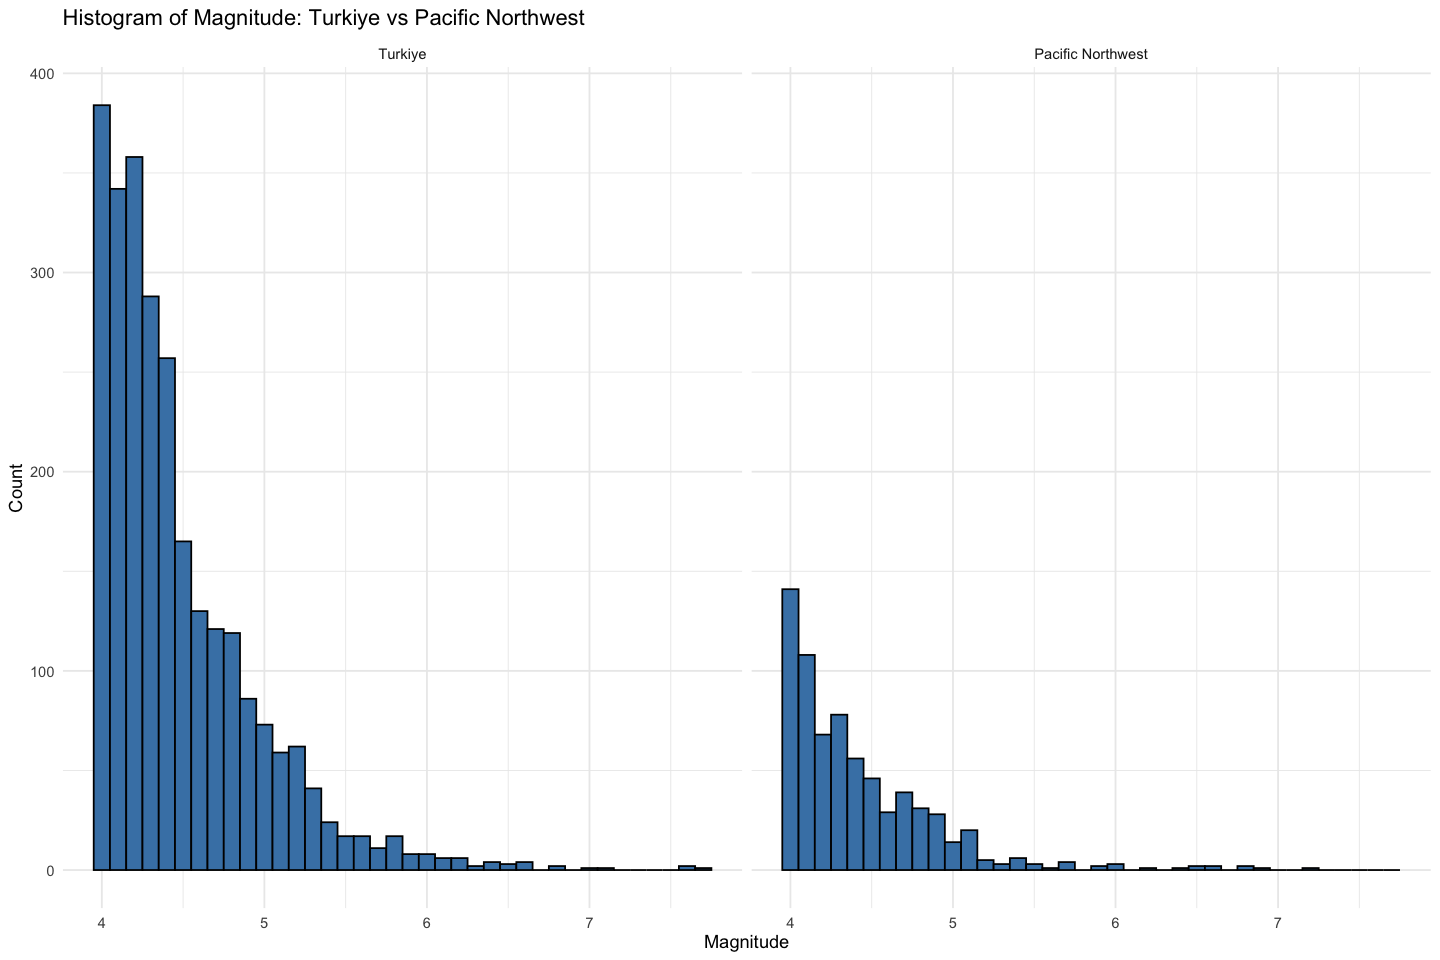

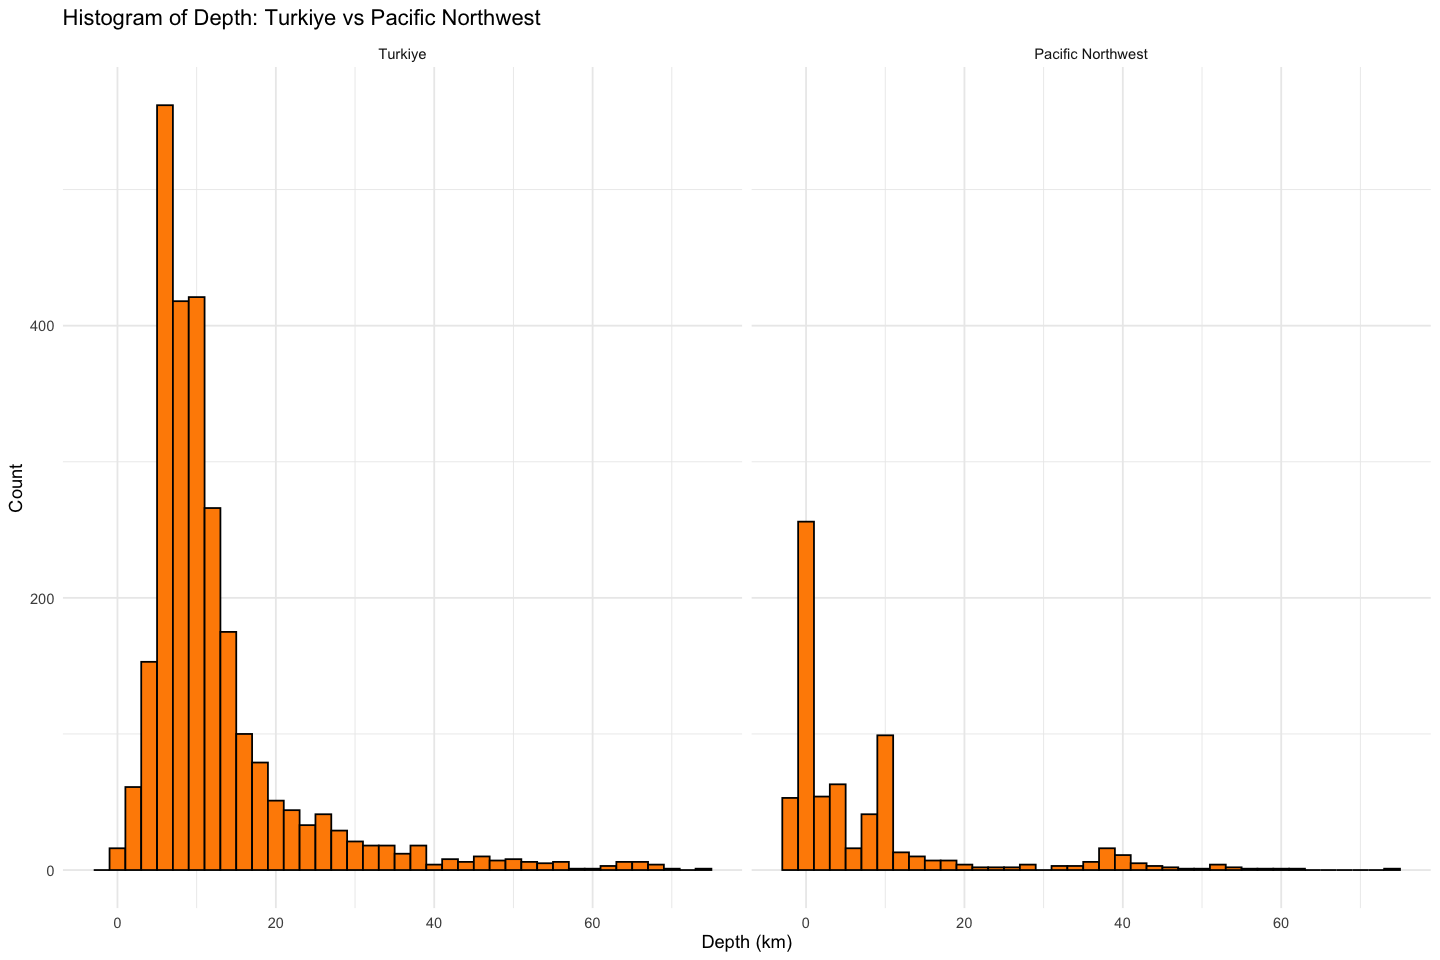

In [66]:
# Add region labels
turkiye$region <- "Turkiye"
pacific_nw$region <- "Pacific Northwest"

# Standardize column names and combine
combined_data$region <- factor(
  combined_data$region,
  levels = c("Turkiye", "Pacific Northwest")
)

ggplot(combined_data, aes(x = Magnitude)) +
  geom_histogram(binwidth = 0.1, fill = "steelblue", color = "black") +
  facet_wrap(~ region) +
  labs(title = "Histogram of Magnitude: Turkiye vs Pacific Northwest",
       x = "Magnitude",
       y = "Count") +
  theme_minimal()

ggplot(combined_data, aes(x = Depth)) +
  geom_histogram(binwidth = 2, fill = "darkorange", color = "black") +
  facet_wrap(~ region) +
  labs(title = "Histogram of Depth: Turkiye vs Pacific Northwest",
       x = "Depth (km)",
       y = "Count") +
  theme_minimal()

The histograms show that both the Pacific Northwest and Türkiye are dominated by moderate, shallow earthquakes, but with some notable differences. In terms of magnitude, both regions have most events clustered between 4.0 and 4.5; however, Türkiye displays a broader spread toward higher magnitudes, with more earthquakes occurring in the 4.5–5.5 range and a slightly heavier upper tail. This suggests that, within the sample, Türkiye experiences relatively more moderate-to-strong events compared to the Pacific Northwest, where frequencies decline more quickly as magnitude increases. Regarding depth, earthquakes in both regions are primarily shallow, but the Pacific Northwest shows a strong concentration at very shallow depths (0–10 km) along with a smaller secondary cluster around 35–45 km, indicating a somewhat bimodal pattern. In contrast, Türkiye’s depth distribution is more continuous, centered around 5–15 km and gradually extending to greater depths, with some deeper outliers. Overall, while both regions are characterized by shallow, mid-magnitude earthquakes, Türkiye exhibits a slightly wider range in both magnitude and depth compared to the Pacific Northwest.

# A tibble: 7 × 3
  SiteCat       corr     n
  <chr>        <dbl> <int>
1 HATAY      0.0579     46
2 IZMIR      0.218     103
3 MALATYA   -0.0102    159
4 MANISA     0.0810     73
5 MUGLA      0.193     196
6 Other      0.117    1980
7 ÇANAKKALE -0.00636    62


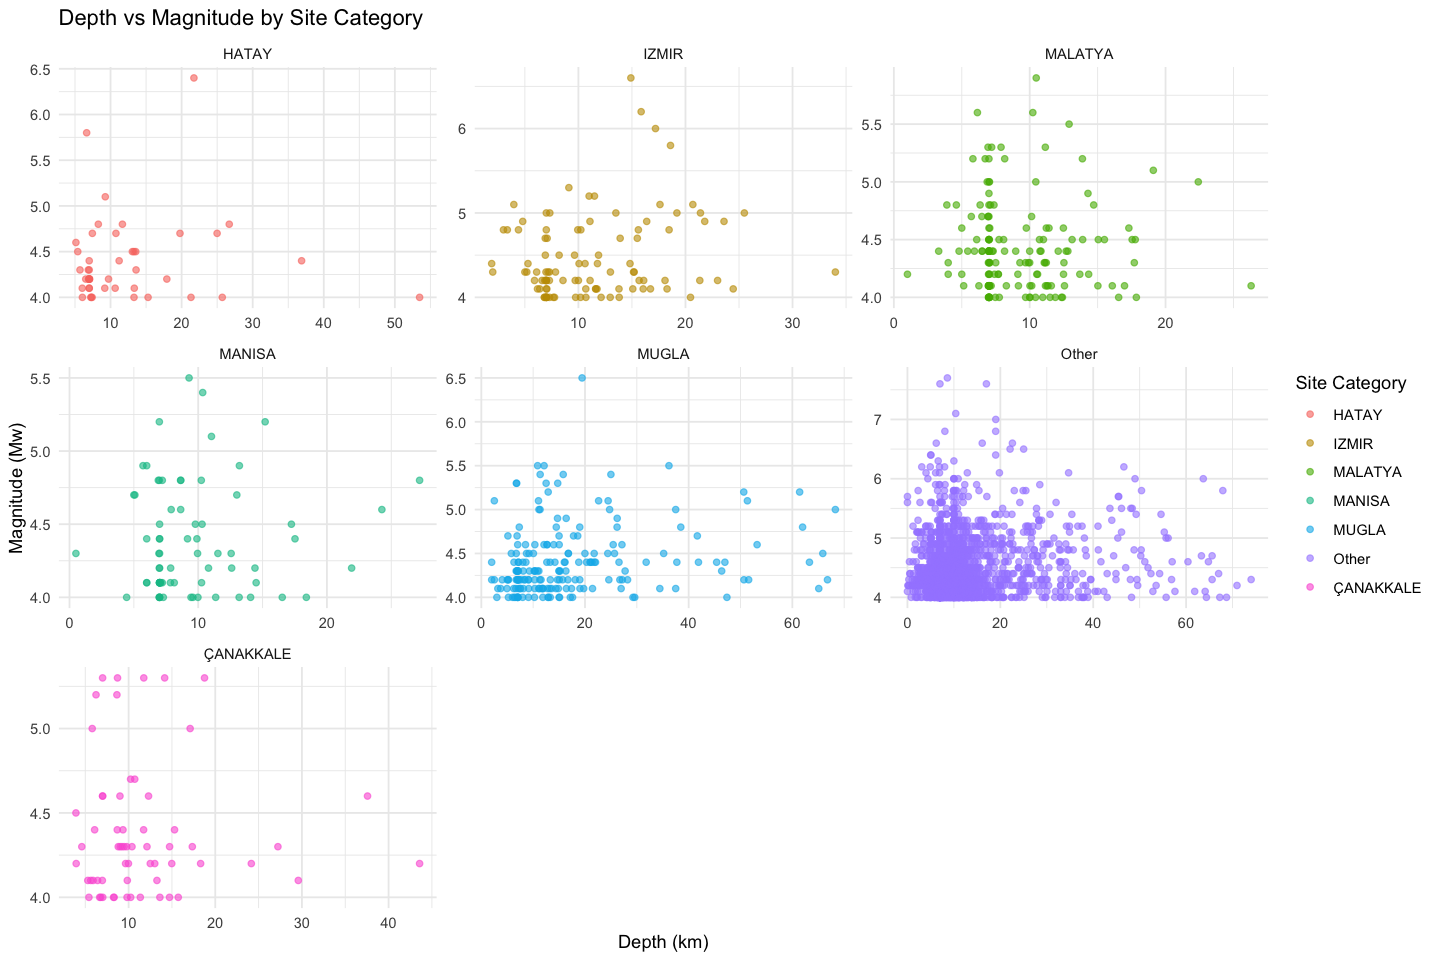

In [63]:
options(repr.plot.width = 12, repr.plot.height = 8)

ggplot(turkiye, aes(x = Depth, y = Magnitude, color = SiteCat)) +
  geom_point(alpha = 0.6) +
  facet_wrap(~SiteCat, scales = "free") +  
  theme_minimal() +
  labs(
    title = "Depth vs Magnitude by Site Category",
    x = "Depth (km)",
    y = "Magnitude (Mw)",
    color = "Site Category"
  )


correlations <- turkiye %>%
  group_by(SiteCat) %>%
  summarise(
    corr = cor(Magnitude, Depth, use = "complete.obs"),
    n = n()
  )

print(correlations)

Across Turkish earthquake sites, the linear correlation between magnitude and depth is generally weak. Some sites like Izmir and Mugla show a slight tendency for deeper earthquakes to have larger magnitudes, but overall, depth explains very little of the variation in magnitude

# A tibble: 5 × 3
  state    corr     n
  <chr>   <dbl> <int>
1 BC    -0.0366    98
2 CA    -0.165     94
3 ID    -0.0794     4
4 OR     0.112    112
5 WA     0.150    387


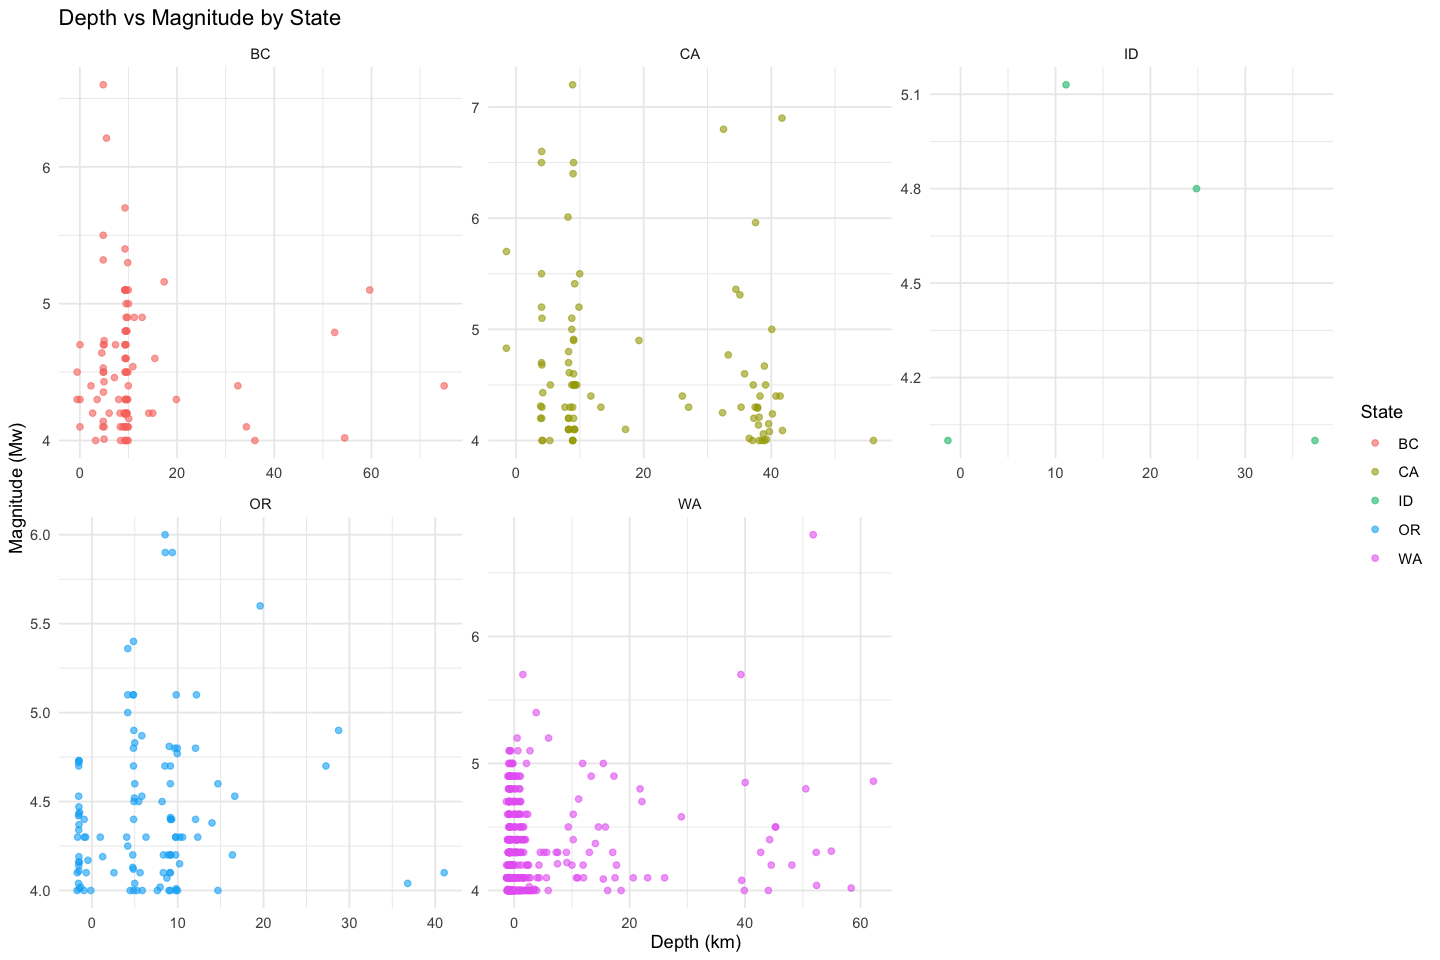

In [62]:
options(repr.plot.width = 12, repr.plot.height = 8)

ggplot(pacific_nw, aes(x = depth, y = magnitude, color = state)) +
  geom_point(alpha = 0.6) +
  facet_wrap(~state, scales = "free") +  
  theme_minimal() +
  labs(
    title = "Depth vs Magnitude by State",
    x = "Depth (km)",
    y = "Magnitude (Mw)",
    color = "State"
  )


correlations <- pacific_nw %>%
  group_by(state) %>%
  summarise(
    corr = cor(magnitude, depth, use = "complete.obs"),
    n = n()
  )

print(correlations)

Across Pacific Northwest and nearby regions, the linear correlation between earthquake depth and magnitude is generally weak. Washington shows a slight positive trend (deeper earthquakes slightly larger), while California shows a weak negative trend. Overall, depth explains little of the variation in magnitude in these regions.

## Measure the Relationship

In [23]:
cor.test(turkiye$Depth, turkiye$Magnitude, method = "spearman")
cor.test(pacific_nw$depth, pacific_nw$magnitude, method = "spearman")


Warning message in cor.test.default(turkiye$Depth, turkiye$Magnitude, method = "spearman"):
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  turkiye$Depth and turkiye$Magnitude
S = 2716720460, p-value = 2.056e-06
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
0.09261881 


Warning message in cor.test.default(pacific_nw$depth, pacific_nw$magnitude, method = "spearman"):
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  pacific_nw$depth and pacific_nw$magnitude
S = 46196398, p-value = 3.782e-06
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.1743312 


Spearman rank correlation between earthquake depth and magnitude is weak but statistically significant in both datasets (Turkey: ρ = 0.09, p < 0.001; Pacific NW: ρ = 0.17, p < 0.001), suggesting a slight tendency for deeper earthquakes to have larger magnitudes

## LOESS Curve

`geom_smooth()` using formula = 'y ~ x'


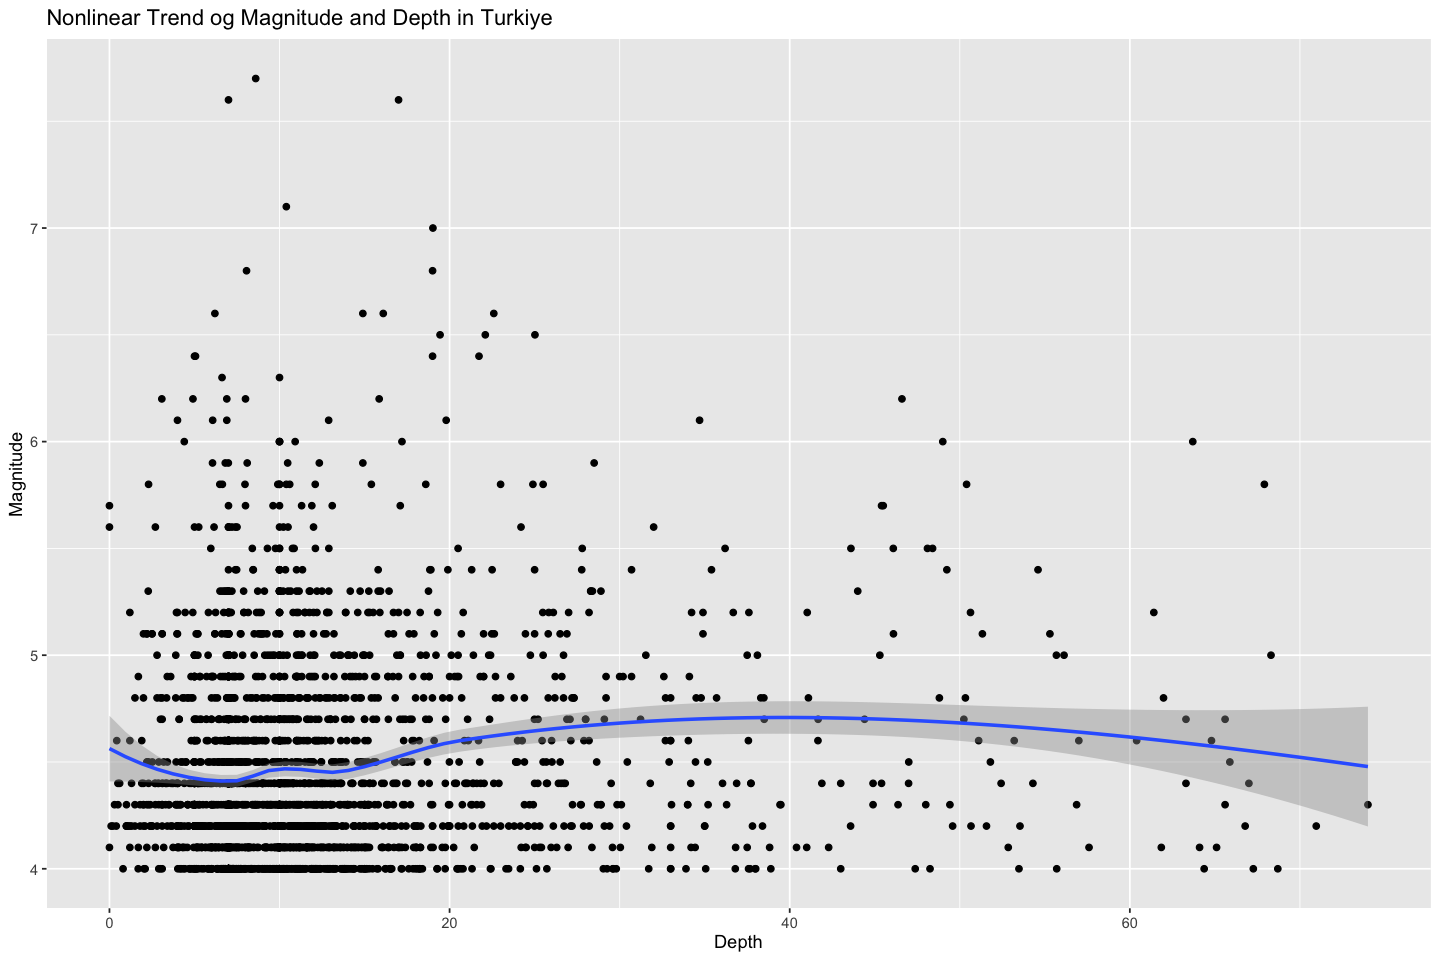

In [18]:
ggplot(turkiye, aes(x = Depth, y = Magnitude)) +
  geom_point() +
  geom_smooth(method = "loess") +
  labs(title = 'Nonlinear Trend og Magnitude and Depth in Turkiye')

In Turkiye, the LOESS curve suggests a weak nonlinear relationship between earthquake depth and magnitude. Magnitude slightly decreases at very shallow depths, then gradually increases and peaks around mid-range depths (approximately 30–40 km), before gently declining again at greater depths. This creates a mild inverted-U shape. However, the overall change in magnitude across depths is small compared to the large vertical spread of the data points, indicating that depth is not a strong predictor of magnitude. The confidence band widens at deeper depths, suggesting greater uncertainty due to fewer observations.

`geom_smooth()` using formula = 'y ~ x'


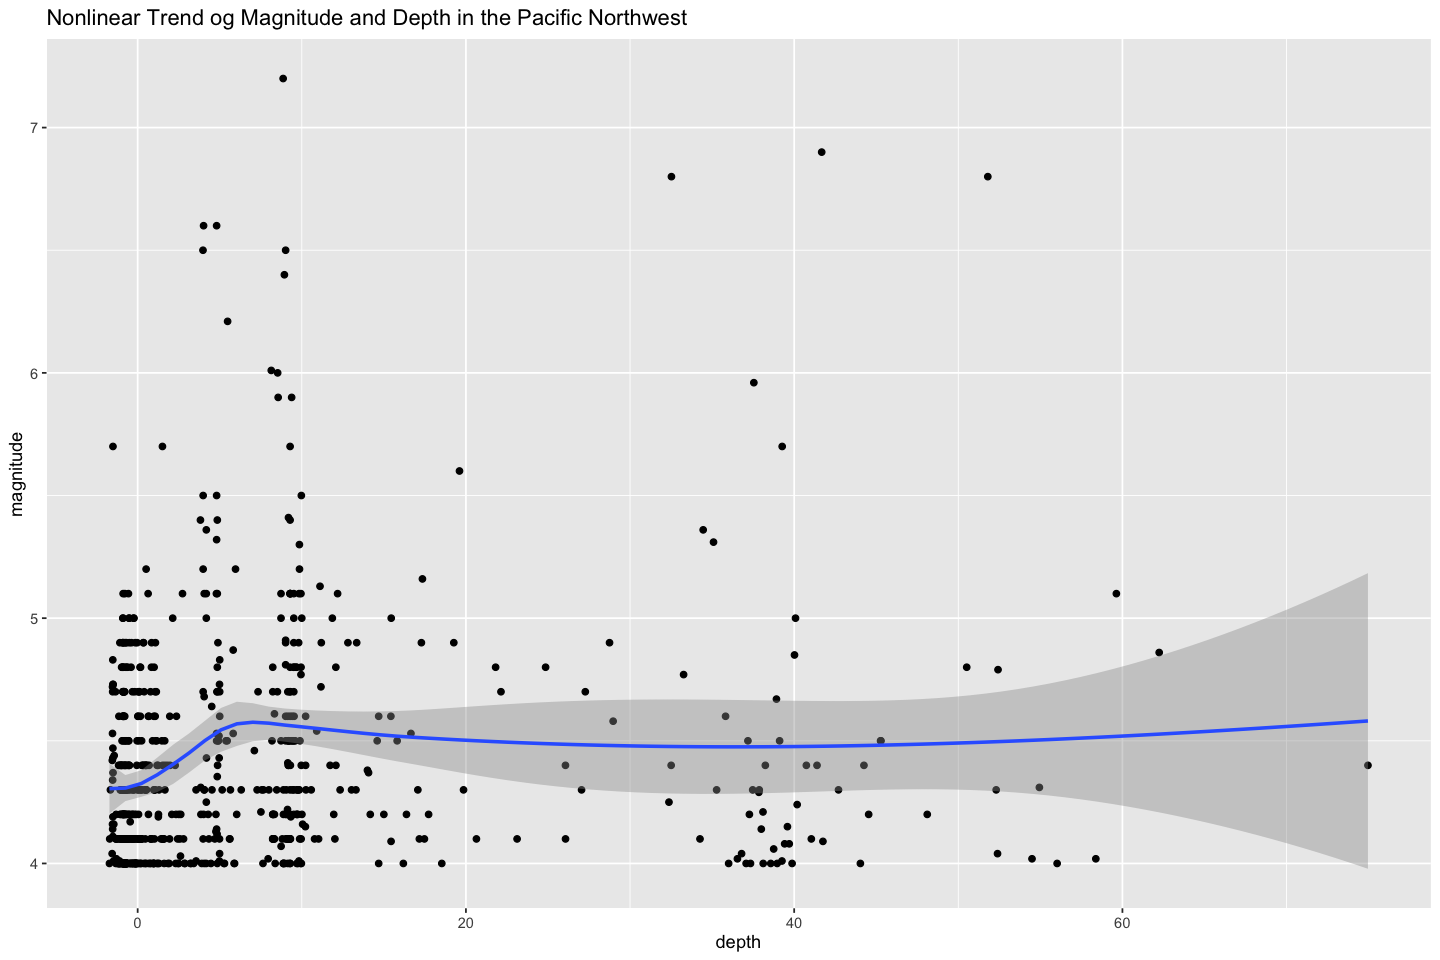

In [19]:
ggplot(pacific_nw, aes(x = depth, y = magnitude)) +
  geom_point() +
  geom_smooth(method = "loess") +
  labs(title = 'Nonlinear Trend og Magnitude and Depth in the Pacific Northwest')

In the Pacific Northwest, the LOESS curve is even flatter, indicating an even weaker relationship between depth and magnitude. Magnitude increases slightly at shallow depths, levels off through mid-depth ranges, and shows a small upward trend again at greater depths, though with wide confidence intervals. The broad scatter of points and minimal curvature suggest that magnitude remains relatively consistent across depths in this region. Overall, both regions show only subtle nonlinear trends, with depth having limited influence on earthquake magnitude.

In both regions:

- The LOESS curve is relatively flat.
- Vertical scatter is much larger than the curve movement.
- This suggests depth is not a strong predictor of magnitude.
- Most variation in magnitude occurs independent of depth.

So statistically, the nonlinear trend exists, but it is subtle and not practically large.

## Compare Regions

In [22]:
turkiye %>%
  group_by(SiteCat) %>%
  summarize(correlation =
    cor(Depth, Magnitude, method = "spearman"))

SiteCat,correlation
<chr>,<dbl>
HATAY,0.05235360
IZMIR,0.15814717
MALATYA,-0.08680501
MANISA,0.02352080
MUGLA,0.25159029
Other,0.09189086
ÇANAKKALE,0.05617918


Across all site categories, the correlations are weak (|ρ| < 0.3), indicating that depth is not strongly associated with magnitude in a monotonic way. Even in the strongest case (MUGLA), the relationship is small and likely not practically significant. This aligns with the LOESS plots, which showed only subtle nonlinear trends rather than strong relationships.

In [21]:
pacific_nw %>%
  group_by(state) %>%
  summarize(correlation =
    cor(depth, magnitude, method = "spearman"))

state,correlation
<chr>,<dbl>
BC,0.03393779
CA,-0.21218535
ID,-0.10540926
OR,0.10877035
WA,0.07958048


Across state in the Pacific Northwest, all values are between –0.3 and 0.3, the relationships are considered weak. This means depth is not a strong predictor of magnitude in any of these states. While California shows the most noticeable trend (slightly negative), the effect remains small and likely not practically significant.

## Classify Depth Groups

In [24]:
turkiye$depth_group <- ifelse(turkiye$Depth <= 20,
                           "Shallow",
                           "Deep")

aggregate(Magnitude ~ depth_group, turkiye, mean)


depth_group,Magnitude
<chr>,<dbl>
Deep,4.609971
Shallow,4.446752


For the Turkiye data, the average magnitude for deep earthquakes (4.61) is slightly higher than for shallow earthquakes (4.45).

This means that, on average, deeper earthquakes tend to have somewhat larger magnitudes compared to shallow ones. However, the difference is small — only about 0.16 magnitude units — which suggests the effect is modest rather than substantial.

In practical terms, while there appears to be a slight tendency for deeper earthquakes in Türkiye to be stronger on average, the difference is not large enough to indicate a strong relationship between depth category and magnitude.

In [25]:
pacific_nw$depth_group <- ifelse(pacific_nw$depth <= 20,
                           "Shallow",
                           "Deep")

aggregate(magnitude ~ depth_group, pacific_nw, mean)

depth_group,magnitude
<chr>,<dbl>
Deep,4.499945
Shallow,4.410968


For the Pacific Northwest data, the average magnitude for deep earthquakes (4.50) is slightly higher than for shallow earthquakes (4.41).

This indicates that deeper earthquakes tend to have marginally larger magnitudes on average. However, the difference is very small — only about 0.09 magnitude units — suggesting that the effect is minimal.

Overall, this small difference implies that earthquake magnitude in the Pacific Northwest does not meaningfully vary between deep and shallow events. Depth category appears to have only a weak influence on magnitude, consistent with the earlier correlation results showing a weak relationship.

Comparing the two regions, both Turkiye and the Pacific Northwest show the same general pattern: deep earthquakes have slightly higher average magnitudes than shallow earthquakes. However, the strength of this difference varies.

In Türkiye, the average magnitude for deep earthquakes (4.61) is higher than for shallow earthquakes (4.45), with a difference of about 0.16 magnitude units. In contrast, in the Pacific Northwest, deep earthquakes (4.50) are only about 0.09 magnitude units stronger on average than shallow ones (4.41).

This means the depth-related difference in magnitude is slightly more pronounced in Turkiye than in the Pacific Northwest. However, in both regions, the differences are small overall, suggesting that depth category has only a modest impact on earthquake magnitude. The general conclusion is that while deeper earthquakes tend to be marginally stronger in both regions, the effect is weak and not practically large.

## Temporal Trends

In [54]:
turkiye_yearly <- turkiye %>% 
    group_by(Year) %>% 
    summarise(mean_magnitude = mean(Magnitude),
              mean_depth = mean(Depth)) %>%
    mutate(year = Year)
              
pnw_yearly <- pacific_nw %>% 
    group_by(year) %>% 
    summarise(mean_magnitude = mean(magnitude),
              mean_depth = mean(depth))

turkiye_yearly <- turkiye_yearly %>% mutate(source = "Turkiye")
pnw_yearly   <- pnw_yearly %>% mutate(source = "Pacific Northwest")

combined_trend <- bind_rows(turkiye_yearly, pnw_yearly)


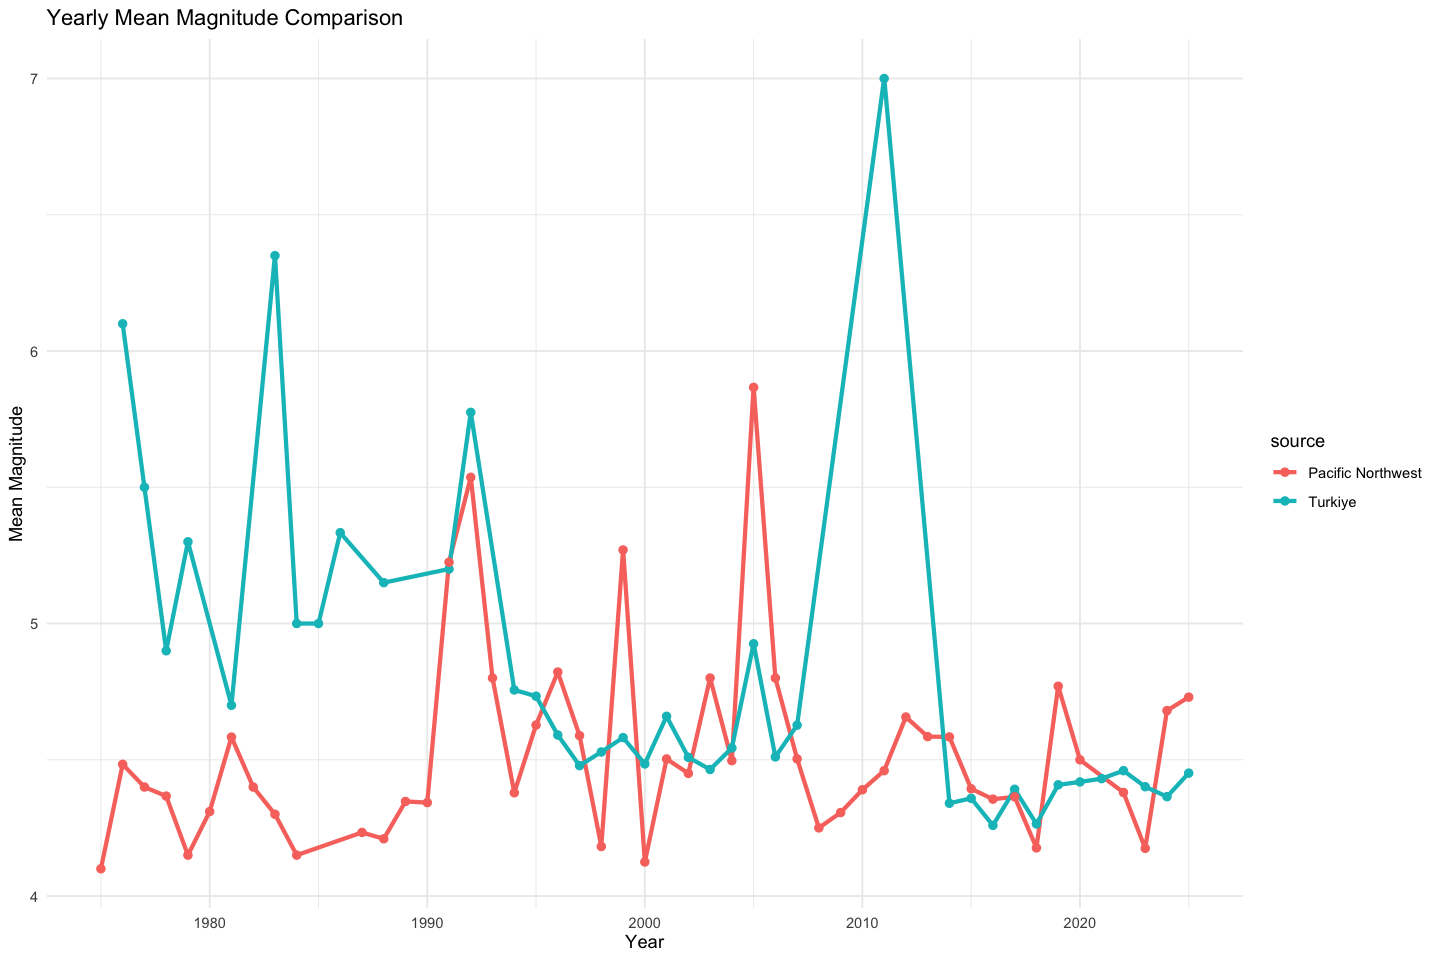

In [55]:
library(ggplot2)

ggplot(combined_trend, aes(x = year, y = mean_magnitude, color = source)) +
  geom_line(size = 1.2) +
  geom_point(size = 2) +
  labs(title = "Yearly Mean Magnitude Comparison", x = "Year", y = "Mean Magnitude") +
  theme_minimal()

Türkiye shows more noticeable fluctuations, including a few strong peak years (especially around 2011), but no consistent upward or downward trend. The Pacific Northwest is more stable overall, with smaller variations and only one notable spike.

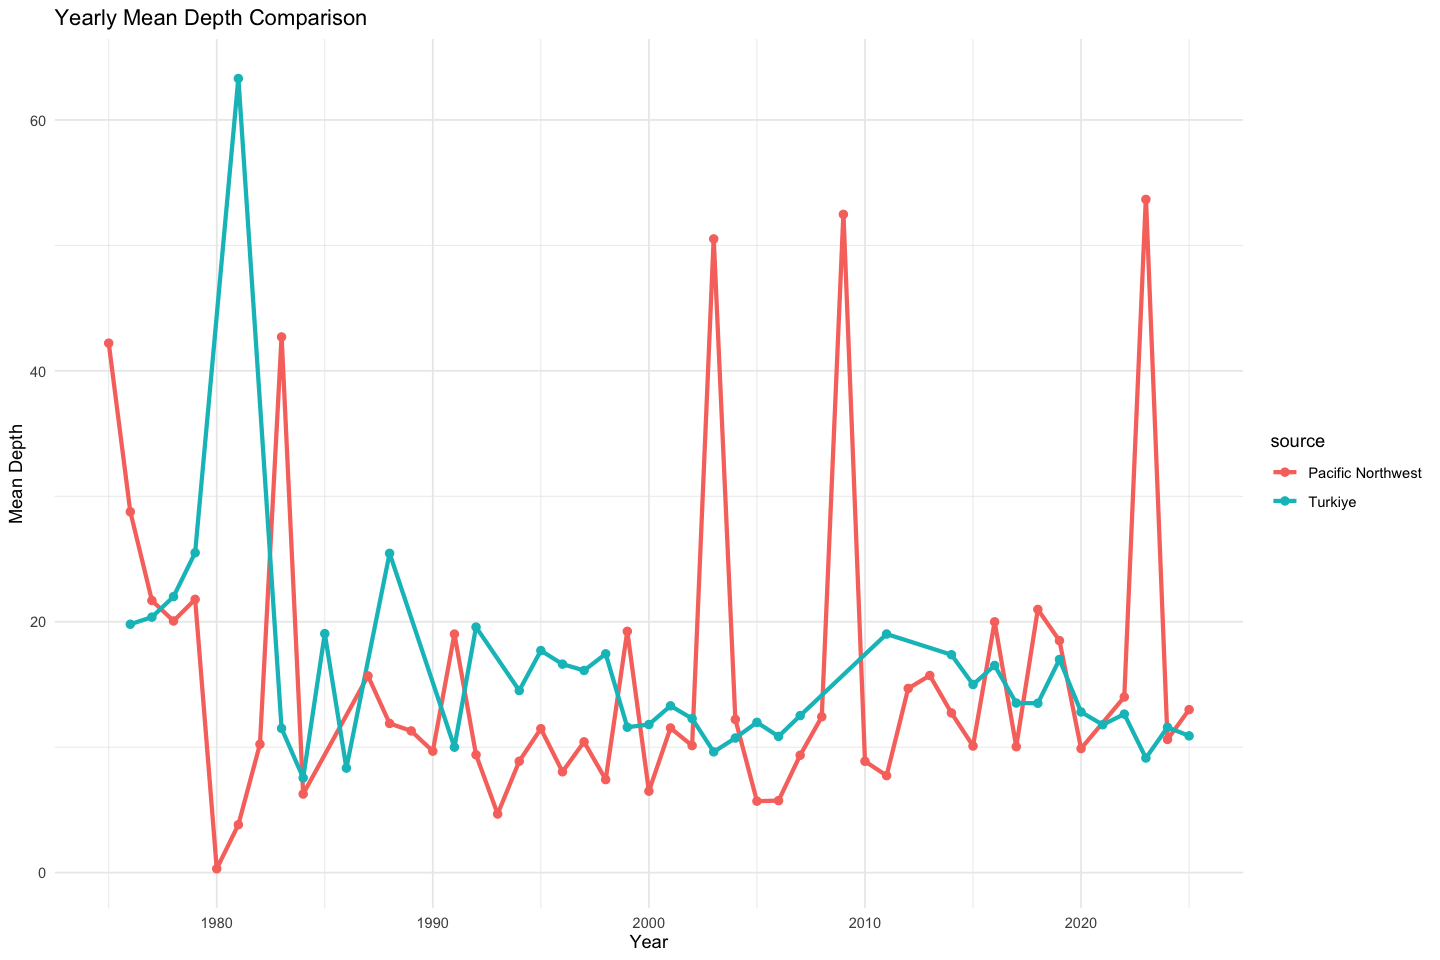

In [56]:
library(ggplot2)

ggplot(combined_trend, aes(x = year, y = mean_depth, color = source)) +
  geom_line(size = 1.2) +
  geom_point(size = 2) +
  labs(title = "Yearly Mean Depth Comparison", x = "Year", y = "Mean Depth") +
  theme_minimal()

Türkiye’s mean earthquake depth is relatively stable over time (mostly 10–20 km) after an early outlier spike, with no clear long-term trend. The Pacific Northwest shows greater variability, with several sharp spikes in certain years, indicating occasional deeper earthquake activity rather than steady change.